In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import gc
from pathlib import Path
from define_data_and_variables import opes_config, opes_hash, data, version

In [2]:
base_dir = Path.cwd()
base_path = base_dir / ".." / ".." / ".." / ".." / "data"

print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"

wah_d18o


In [3]:
base_dir = Path.cwd()
dir = base_dir / f"output/{data["dn"]}/{version}"
output_dir = dir / f"{opes_hash}"
print(output_dir)
hmc_config = opes_config["hmcc"]

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\OPES\output\wah_d18o\0\4e8bba5603


In [4]:
color_list = plt.cm.viridis(np.linspace(0, 1, np.min((hmc_config["nch"], 5))))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

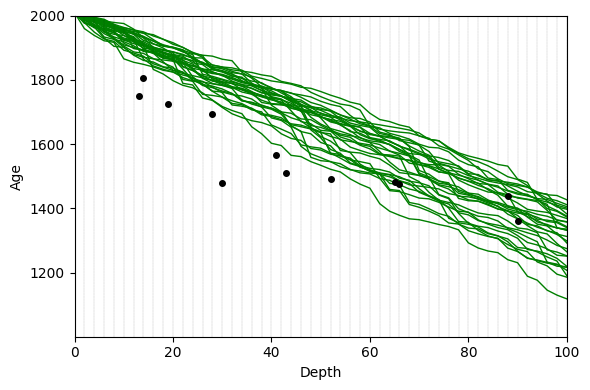

In [ ]:

cumulative_sums = np.cumsum(hmc_config["sp"], axis=1) * data["dc"]
zeros = np.zeros((*hmc_config["sp"].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)

model_ages = data["th"] - age_offsets

# Starting points
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(hmc_config["sp"])
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(np.min(data["d18ort"]), np.max(data["d18ort"]))
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{dir}/sp_age_depth.jpg")
plt.show()

In [6]:
base_dir = Path.cwd()
df = np.load(f"{output_dir}/df.npy", mmap_mode = "r")

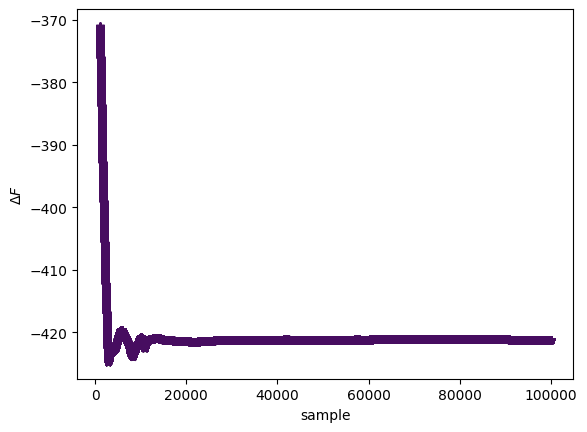

In [ ]:
fig, ax = plt.subplots()
ind = -1
chain = 0
x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
sample_delta_F = np.squeeze(df[chain, :, -1])
ax.plot(x[1000:], sample_delta_F[1000:], '*-', color = temp_colors[1])
plt.xlabel(f"sample")
plt.ylabel(r"$\Delta F$")
plt.savefig(f"{output_dir}/df_{ind}.jpg")
plt.show()


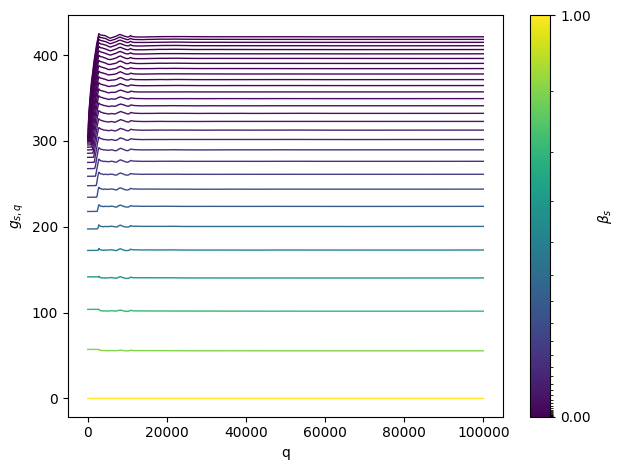

In [ ]:
import matplotlib as mpl
fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=min(opes_config['bs']), vmax=max(opes_config['bs']))
cmap = plt.cm.viridis

for k in range(opes_config["nt"]):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:], -sample_delta_F[:], '-', linewidth = 1, color=cmap(norm(opes_config['bs'][k])), label = fr"$\beta_{{{k}}} = $" + f"{opes_config['bs'][k]:.2f}")

plt.xlabel(f"q")
plt.ylabel(r"$g_{s, q}$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\beta_s$")
ticks = [min(opes_config["bs"]), max(opes_config["bs"])]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_minor_locator(
    plt.FixedLocator(opes_config["bs"])
)

plt.tight_layout()
plt.savefig(f"{output_dir}/gs.jpg")
plt.show()


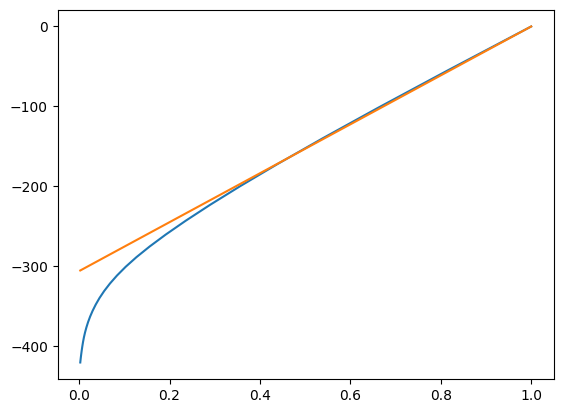

In [11]:
plt.figure()
plt.plot(opes_config["bs"], df[0, 5000, :])
plt.plot(opes_config["bs"], opes_config["df"])
plt.show()

In [12]:
del df
gc.collect()

9085

In [13]:
cutout = 10000
bias_values = np.load(f"{output_dir}/bias.npy", mmap_mode='r')[:, cutout:]
energy_values = np.load(f"{output_dir}/energy.npy", mmap_mode='r')[:, cutout:]


In [14]:
neff = np.sum(np.exp(bias_values), axis = 1)**2 / np.sum(np.exp(bias_values)**2, axis = 1)
print(neff)

[6578.55527703 4773.80595332 3655.277746   4325.42250247 6192.44538217
 5308.45415783 6338.10866051 6202.25873172 4531.03545733 2520.51699348
 7343.41636958 3350.02263857 2157.64547622 7992.02430448 4961.90045586
 6095.4027317  4581.29673625 6124.96041105 5258.67441226 6618.63781526
 9838.8097036  3444.18822656 8387.00458993 4533.75183134 5773.98051718
 7328.01349735 5508.46768679 4452.3248643  8171.86765697 7871.54907431]


In [15]:
print(np.sum(neff))

170219.81986144456


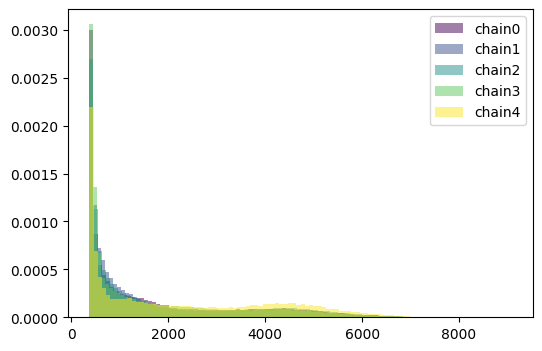

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(np.min((hmc_config["nch"], 5))):
    ax.hist(energy_values[i, cutout:], color = color_list[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [47]:
print(np.min(energy_values))
print(np.max(bias_values))

368.71204377441256
3.2544723587433033


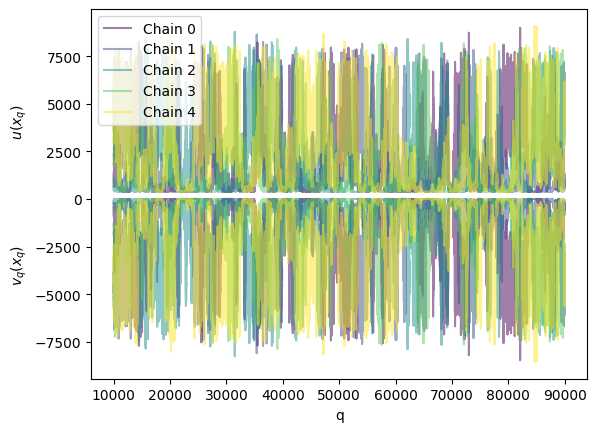

In [48]:
plt.figure()
for i in range(np.min((hmc_config["nch"], 5))):
    plt.plot(np.linspace(cutout, len(bias_values[0, :] + cutout), len(bias_values[i, :])), bias_values[i, :], color = color_list[i], alpha = 0.5, label = f"Chain {i}")
    plt.plot(np.linspace(cutout, len(bias_values[0, :] + cutout), len(bias_values[i, :])), energy_values[i, :], color = color_list[i], alpha = 0.5)
plt.xlabel("q")
plt.ylabel(r"$v_q(x_q)$                        $u(x_q)$")
plt.legend()
plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

In [16]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [51]:
print(az.summary(samples))

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    8.955  5.334   5.111   17.845      0.060    0.097   18575.0   12552.0   
x[1]   15.707  5.796   2.029   19.527      0.056    0.096   11362.0   15255.0   
x[2]   23.764  7.943   2.331   31.117      0.110    0.131   11389.0   12082.0   
x[3]    8.240  6.424   0.983   18.295      0.062    0.113   53436.0   13187.0   
x[4]    6.483  6.215   0.894   15.820      0.064    0.116   28760.0   12336.0   
x[5]    9.374  9.251   1.165   25.926      0.122    0.154    8881.0   12689.0   
x[6]   28.652  9.954   3.316   38.722      0.156    0.137    6685.0   13528.0   
x[7]    8.916  5.030   0.972   18.027      0.021    0.062  153813.0   24433.0   
x[8]   15.652  6.067   1.825   25.491      0.049    0.075   16759.0   17295.0   
x[9]    7.034  3.399   1.494   13.141      0.017    0.037   91344.0   27409.0   
x[10]   8.448  3.714   1.962   12.706      0.066    0.013    3607.0   29111.0   
x[11]   2.937  2.632   0.377

In [17]:
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(hmc_config["nch"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(hmc_config["nch"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(hmc_config["nch"])]

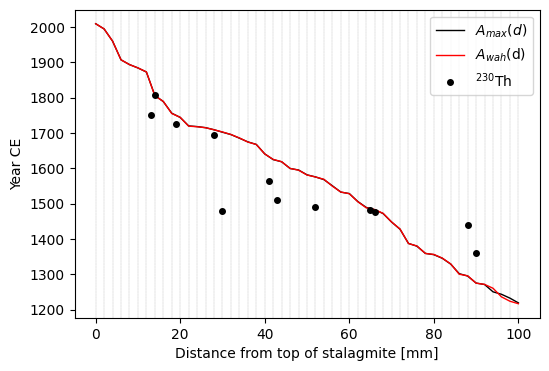

In [19]:
chain = 0
fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
plt.show()



C:\Users\hanna\AppData\Local\Temp\ipykernel_56160\1556759067.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(


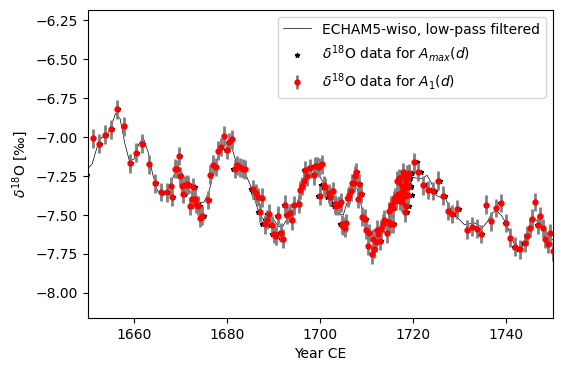

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
ax.errorbar(
    data["d18ota"], 
    data["d18o"], 
    yerr=data["d18os"],      
    color="red", 
    ecolor = "grey",
    fmt = ".k", 
    markersize=7,                
    linestyle="None",           
    elinewidth=2,
    label=r"$\delta^{18}$O data for $A_1(d)$"
)

ax.scatter(
    np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), 
    data["d18o"], 
    color="black", 
    marker="*", 
    s=10,
    label=r"$\delta^{18}$O data for $A_{max}(d)$"
)
plt.xlim((1650, 1750))
plt.ylabel("$\\delta^{18}$O [‰]")
plt.xlabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/data_compare.jpg")
plt.show()


In [20]:
resampled_samples = []
weights = np.exp(bias_values)
for i in range(hmc_config["nch"]):
    weights_i = weights[i, :] / sum(weights[i, :])

    indices = np.random.choice(
        np.arange(0, len(weights_i)),
        size=10000,
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

resampled_samples = np.array(resampled_samples)

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 5 done resampling
Chain 6 done resampling
Chain 7 done resampling
Chain 8 done resampling
Chain 9 done resampling
Chain 10 done resampling
Chain 11 done resampling
Chain 12 done resampling
Chain 13 done resampling
Chain 14 done resampling
Chain 15 done resampling
Chain 16 done resampling
Chain 17 done resampling
Chain 18 done resampling
Chain 19 done resampling
Chain 20 done resampling
Chain 21 done resampling
Chain 22 done resampling
Chain 23 done resampling
Chain 24 done resampling
Chain 25 done resampling
Chain 26 done resampling
Chain 27 done resampling
Chain 28 done resampling
Chain 29 done resampling


In [21]:
chain = 0
index = 12
interesting_depth = index * data["dc"]

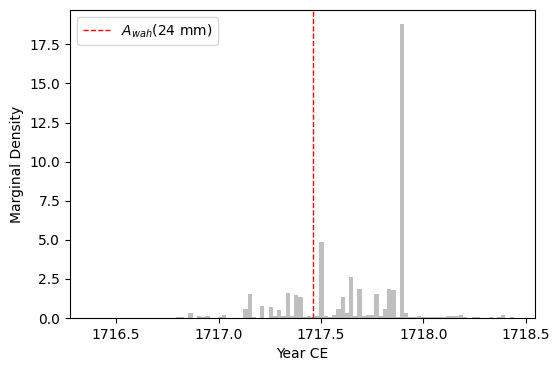

In [22]:
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[chain][:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


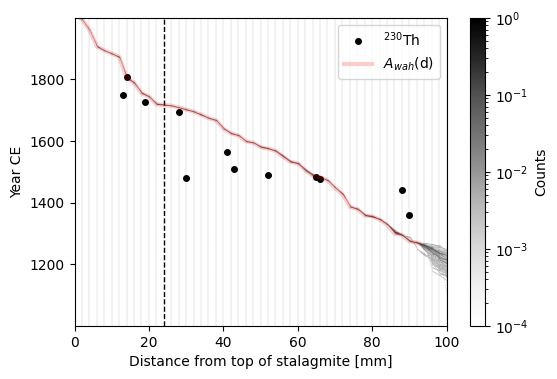

In [23]:
from matplotlib import colors

X = resampled_samples[chain].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = data["H"] / 1000
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for j in range(Z):
    C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    linewidth = 0.1 if i != index else 1
    ax.axvline(x=c, color='k', linestyle='--', linewidth = linewidth)


ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["d18od"], data["d18ota"], color = "red", linewidth=3, alpha = 0.2, label = f"{data_name}(d)")

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Counts")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/ad_samples_chain_{chain}.jpg")
plt.show()